# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [23]:
import re
import pandas as pd
import spacy
import requests
import bs4 as bs
import yfinance as yf
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

### Dataset

### Web scraping

In [2]:
url = 'http://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/111.0.0.0 Safari/537.36'
}

resp = requests.get(url, headers=headers) 
soup = bs.BeautifulSoup(resp.text, 'lxml')

table = soup.find('table', {'id': 'constituents'})
tickers = []

for row in table.find_all('tr')[1:]:  
    cols = row.find_all('td')
    if cols:  
        ticker = cols[0].text.strip()
        tickers.append(ticker)

print(len(tickers))  
tickers

503


['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK.B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF.B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'KMX',
 'CCL',
 'CARR',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'CAG',
 'COP',
 'ED',
 'STZ',
 'CEG',


## Tasks

### Task #1: Basic manipulation and descriptive statistics

#### • Import the Data_PCLab3_Twitter_Stock_Sentiment.csv data and describe the sample (data available on BBoard)

In [3]:
df = pd.read_csv("Data_PCLab3_Twitter_Stock_Sentiment.csv")

In [4]:
df.head()

,Text,Sentiment
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1
2,user I'd be afraid to short AMZN - they are lo...,1
3,MNTA Over 12.00,1
4,OI Over 21.37,1


In [5]:
df.describe()

,Sentiment
count,5791.000000
mean,0.636332
std,0.481096
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [6]:
df['tweet_length'] =  df['Text'].str.len()

#### • How many tweets, how many words per tweets, distribution of number of words per tweets, average sentiment, etc.

In [7]:
print("Number of tweets = ",len(df))
print("Average number of words per tweet:", df['tweet_length'].mean())
print("Average sentiment =", df['Sentiment'].mean())

Number of tweets =  5791
Average number of words per tweet: 78.55931618027975
Average sentiment = 0.6363322396822656


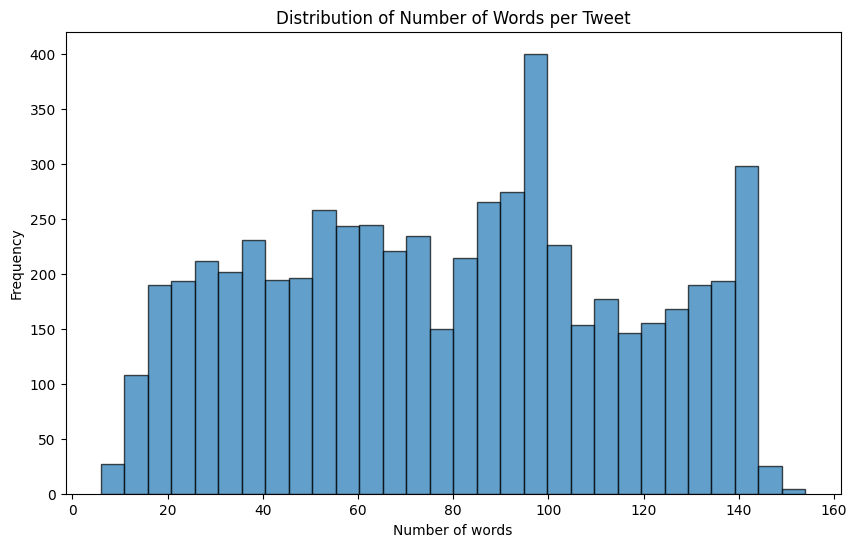

In [70]:
plt.figure(figsize=(10,6))
plt.hist(df['tweet_length'], bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribution of Number of Words per Tweet")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
sentiment_1 = df[df['Sentiment'] == 1]
len_sentiment_1 = len(sentiment_1)
print(f'Number of tweets from POSITIVE sentiment: {len_sentiment_1}')

sentiment_0 = df[df['Sentiment'] == 0]
len_sentiment_0 = len(sentiment_0)
print(f'Number of tweets from NEGATIVE sentiment: {len_sentiment_0}')

Number of tweets from POSITIVE sentiment: 3685
Number of tweets from POSITIVE sentiment: 2106


### Task #2 : Cleaning and Visualization

#### Usual cleaning steps:
– cleaning URLs, mentions, hashtags, emojis

– tokenization, lemmatization, stopword removal

– tweet-specific text preprocessing with ekphrasis (normalizes hashtags,
elongated words, emoticons).

In [60]:
def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    # Remove URLs
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    # Remove emojis & non-alphanumeric chars (except basic punctuation)
    text = re.sub(r'[^\w\s,.!?]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Clean_Text'] = df['Text'].apply(clean_tweet)

In [65]:
preprocessed_df = df.copy()
nlp = spacy.load("en_core_web_sm", disable=["ner","parser","textcat"])

def process_text(text):
    text = text.lower()
    doc = nlp(text)
    tokens = []
    for token in doc:
        # filter stopwords & punctuation & very short tokens
        if token.is_stop or token.is_punct:
            continue
        # use lemma form
        lemma = token.lemma_.strip()
        if lemma:
            tokens.append(lemma)
    return tokens

preprocessed_df['New_clean_Text'] = preprocessed_df['Clean_Text'].apply(process_text)

In [66]:
preprocessed_df.head()

,Text,Sentiment,tweet_length,Clean_Text,New_clean_Text
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1,95,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,"[kicker, watchlist, xide, tit, soq, pnk, cpw, ..."
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1,95,user AAP MOVIE. 55 return for the FEAGEED indi...,"[user, aap, movie, 55, return, feageed, indica..."
2,user I'd be afraid to short AMZN - they are lo...,1,114,user Id be afraid to short AMZN they are looki...,"[user, d, afraid, short, amzn, look, like, nea..."
3,MNTA Over 12.00,1,17,MNTA Over 12.00,"[mnta, 12.00]"
4,OI Over 21.37,1,16,OI Over 21.37,"[oi, 21.37]"


#### Plot a word cloud for text with positive and negative sentiment separately

In [67]:
prep_sen_1 = preprocessed_df[preprocessed_df['Sentiment'] == 1]
prep_sen_0 = preprocessed_df[preprocessed_df['Sentiment'] == 0]

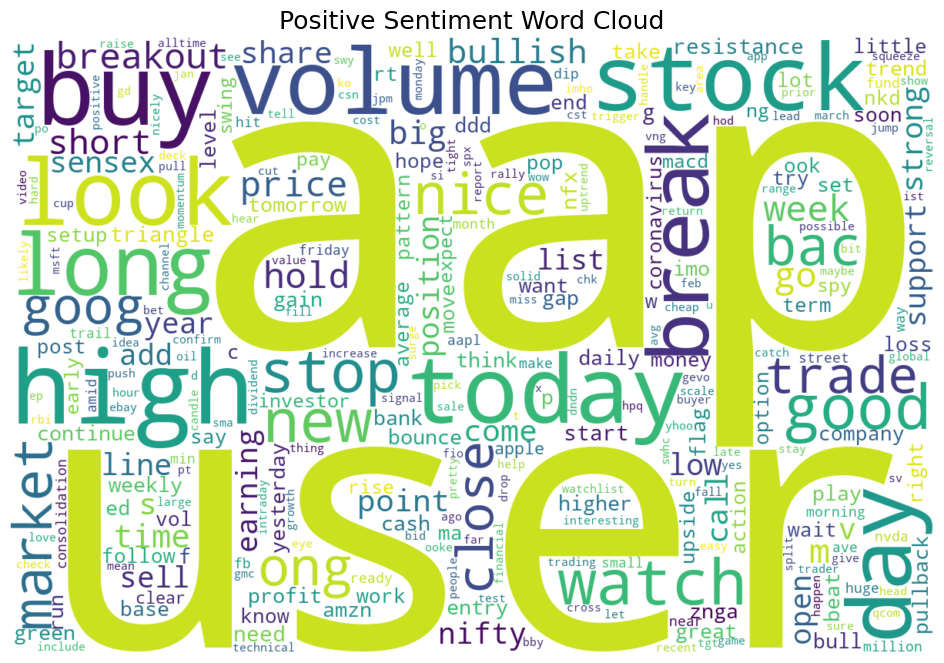

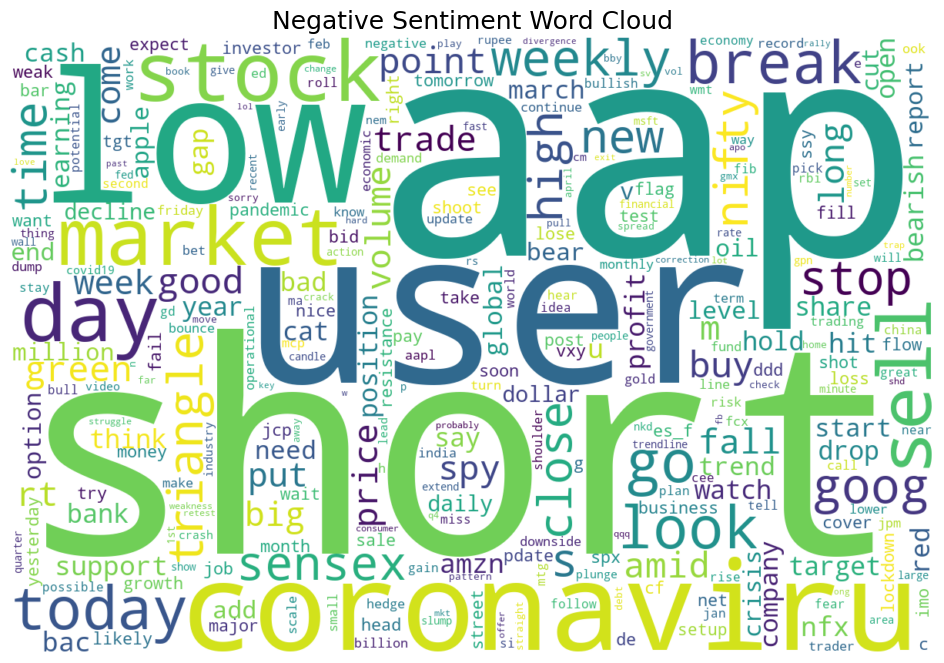

In [68]:
def plot_wordcloud(df, col, title):
    # Join token lists into a single string
    text = " ".join([" ".join(tokens) for tokens in df[col]])
    
    wc = WordCloud(
        width=1200,
        height=800,
        background_color="white",
        stopwords=STOPWORDS,
        collocations=False,
        max_words=300
    ).generate(text)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.show()

plot_wordcloud(prep_sen_1, "New_clean_Text", "Positive Sentiment Word Cloud")
plot_wordcloud(prep_sen_0, "New_clean_Text", "Negative Sentiment Word Cloud")

#### • What is the number of unique words?

In [69]:
all_tokens = [tok for tokens in preprocessed_df['New_clean_Text'] for tok in tokens]

unique_words = set(all_tokens)
num_unique_words = len(unique_words)

print("Number of unique words:", num_unique_words)

Number of unique words: 9477


In [71]:
df.head()

,Text,Sentiment,tweet_length,Clean_Text
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1,95,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1,95,user AAP MOVIE. 55 return for the FEAGEED indi...
2,user I'd be afraid to short AMZN - they are lo...,1,114,user Id be afraid to short AMZN they are looki...
3,MNTA Over 12.00,1,17,MNTA Over 12.00
4,OI Over 21.37,1,16,OI Over 21.37


### Task #3 : Sentiment analysis

Matching tweets with stocks to create "labels". The matching is performed using case-sensitive search:

In [ ]:
def find_tickers(text, tickers):
    if not isinstance(text, str):
        return []
    found = []
    for t in tickers:
        pattern = rf'({t}\b|\b{t}\b)'
        if re.search(pattern, text):
            found.append(t)
    return found

df['stocks_mentioned'] = df['Text'].apply(lambda x: find_tickers(x, tickers))
preprocessed_df['stocks_mentioned'] = preprocessed_df['Text'].apply(lambda x: find_tickers(x, tickers))

In [75]:
df.head()

,Text,Sentiment,tweet_length,Clean_Text,stocks_mentioned
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1,95,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,"[T, DE, IT, J, K]"
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1,95,user AAP MOVIE. 55 return for the FEAGEED indi...,"[A, ED, D, EA]"
2,user I'd be afraid to short AMZN - they are lo...,1,114,user Id be afraid to short AMZN they are looki...,[AMZN]
3,MNTA Over 12.00,1,17,MNTA Over 12.00,[A]
4,OI Over 21.37,1,16,OI Over 21.37,[]


In [76]:
preprocessed_df.head()

,Text,Sentiment,tweet_length,Clean_Text,New_clean_Text,stocks_mentioned
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1,95,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,"[kicker, watchlist, xide, tit, soq, pnk, cpw, ...","[T, DE, IT, J, K]"
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1,95,user AAP MOVIE. 55 return for the FEAGEED indi...,"[user, aap, movie, 55, return, feageed, indica...","[A, ED, D, EA]"
2,user I'd be afraid to short AMZN - they are lo...,1,114,user Id be afraid to short AMZN they are looki...,"[user, d, afraid, short, amzn, look, like, nea...",[AMZN]
3,MNTA Over 12.00,1,17,MNTA Over 12.00,"[mnta, 12.00]",[A]
4,OI Over 21.37,1,16,OI Over 21.37,"[oi, 21.37]",[]


#### • Tweet sentiment is provided (1 vs. 0) — Should you trust it?

#### • To produce your own sentiment analysis, use either :
– Pretrained transformer (e.g., Twitter-RoBERTa, FinBERT)

– GPT-style LLM zero-shot/few-shot classification

#### • What is the performance of these methods on financial tweets? I.e., compare it to the original classification.

### Task #4 : Measuring media attention (1)

• Use the list of tickers gathered during last PC Lab (see the web-scrapping part) to compute the number of tweets about each stock

– e.g., AAPL: 36 tweets, 12 negative, 24 positive

#### Rank the stocks by their amount of total media attention, or, alternatively : positive and negative media attention, level of disagreement (dispersion), etc.

#### • Create 10 portfolios based on your preferred measure of media attention

#### • Do you see a correlation between media attention g and stock returns?

#### • If yes, could Twitter attention is likely to be a good factor?

#### • Optional : same, but use FF-5 factors to purge returns from what a traditional model predicts, and plot media attention vs. erros

#### Download the Fama–French 5 factors (Mkt-RF, SMB, HML, RMW, CMA, and RF) from Ken French’s Data Library

#### • Regress the stock’s excess returns on these five factors

####  Save the residuals from this regression. These represent the component of returns unexplained by traditional risk factors (abnormal returns).

#### • Redo same plot (see previous slide), but residuals vs. media attention.